# TODO
- Normalized data
- visualization

### Import required libraries
Import pandas, numpy, seaborn, and matplotlib for data manipulation and visualization.

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Suppress warnings
Configure the warnings module to ignore non‑critical warnings.

In [78]:
import warnings

warnings.filterwarnings("ignore")

### Pull dataset and anomalies from database

In [ ]:
from src.db.analyzer import FraudAnalyzer

analyzer = FraudAnalyzer()

df_train = analyzer.get_ml_feature()
df_anomalies = analyzer.get_anomalies()

Fetching Feature Table for ML
Scanning for anomalous transactions


In [80]:
df = pd.DataFrame(df_train)

### 1.Inspect Data

In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_amount            50000 non-null  float64
 1   account_balance               50000 non-null  float64
 2   daily_transaction_count       50000 non-null  int64  
 3   avg_transaction_amount_7d     50000 non-null  float64
 4   failed_transaction_count_7d   50000 non-null  int64  
 5   card_age                      50000 non-null  int64  
 6   transaction_distance          50000 non-null  float64
 7   risk_score                    50000 non-null  float64
 8   ip_address_flag               50000 non-null  int64  
 9   previous_fraudulent_activity  50000 non-null  int64  
 10  is_weekend                    50000 non-null  int64  
 11  feature_hour                  50000 non-null  float64
 12  feature_day_of_week           50000 non-null  float64
 13  transaction_

In [82]:
df.shape

(50000, 19)

In [83]:
df.sample(5)

,transaction_amount,account_balance,daily_transaction_count,avg_transaction_amount_7d,failed_transaction_count_7d,card_age,transaction_distance,risk_score,ip_address_flag,previous_fraudulent_activity,is_weekend,feature_hour,feature_day_of_week,transaction_type,device_type,location,merchant_category,authentication_method,target
39947,2.30,97087.44,9,82.49,0,41,3326.60,0.9957,0,0,0,19.0,5.0,Online,Tablet,New York,Restaurants,PIN,1
25173,20.19,71301.18,7,198.40,4,55,2174.94,0.8365,0,0,0,21.0,2.0,ATM Withdrawal,Mobile,Mumbai,Electronics,Biometric,1
14224,50.23,64850.61,12,61.75,1,94,1201.69,0.4175,0,0,0,2.0,1.0,ATM Withdrawal,Mobile,Mumbai,Electronics,Biometric,0
36853,137.83,26013.62,3,374.99,0,51,1951.77,0.7433,0,0,0,15.0,0.0,ATM Withdrawal,Laptop,Mumbai,Clothing,PIN,0
42272,81.48,7326.72,3,161.94,4,80,4970.15,0.8128,1,0,0,3.0,3.0,Online,Laptop,New York,Restaurants,OTP,1


### 2.Verify Missing Values
Count missing values per column to ensure data completeness.

In [84]:
df.isnull().sum()

transaction_amount              0
account_balance                 0
daily_transaction_count         0
avg_transaction_amount_7d       0
failed_transaction_count_7d     0
card_age                        0
transaction_distance            0
risk_score                      0
ip_address_flag                 0
previous_fraudulent_activity    0
is_weekend                      0
feature_hour                    0
feature_day_of_week             0
transaction_type                0
device_type                     0
location                        0
merchant_category               0
authentication_method           0
target                          0
dtype: int64


- No columns contain null values

### 3.Detect Duplicate Rows

In [85]:
df.duplicated().sum()

np.int64(0)

- No duplicate rows

### 4.Fix Data Types

In [86]:
df["feature_day_of_week"] = df["feature_day_of_week"].astype(int)
df["feature_hour"] = df["feature_hour"].astype(int)

df["transaction_type"] = df["transaction_type"].astype("category")
df["device_type"] = df["device_type"].astype("category")
df["location"] = df["location"].astype("category")
df["merchant_category"] = df["merchant_category"].astype("category")
df["authentication_method"] = df["authentication_method"].astype("category")

### 5.Summary Statistics For Numeric Features

In [88]:
df.describe(include= [np.number]).T

,count,mean,std,min,25%,50%,75%,max
transaction_amount,50000.0,99.411012,98.687292,0.0000,28.6775,69.66000,138.852500,1174.14
account_balance,50000.0,50294.065981,28760.458557,500.4800,25355.9950,50384.43000,75115.135000,99998.31
daily_transaction_count,50000.0,7.485240,4.039637,1.0000,4.0000,7.00000,11.000000,14.00
avg_transaction_amount_7d,50000.0,255.271924,141.382279,10.0000,132.0875,256.08500,378.032500,500.00
failed_transaction_count_7d,50000.0,2.003540,1.414273,0.0000,1.0000,2.00000,3.000000,4.00
card_age,50000.0,119.999940,68.985817,1.0000,60.0000,120.00000,180.000000,239.00
transaction_distance,50000.0,2499.164155,1442.013834,0.2500,1256.4975,2490.78500,3746.395000,4999.93
risk_score,50000.0,0.501556,0.287774,0.0001,0.2540,0.50225,0.749525,1.00
ip_address_flag,50000.0,0.050200,0.218360,0.0000,0.0000,0.00000,0.000000,1.00
previous_fraudulent_activity,50000.0,0.098400,0.297858,0.0000,0.0000,0.00000,0.000000,1.00


### 6.Summary Statistics For Categorical Features

In [99]:
df.describe(include= ["category"]).T

,count,unique,top,freq
transaction_type,50000,4,POS,12549
device_type,50000,3,Tablet,16779
location,50000,5,Tokyo,10208
merchant_category,50000,5,Clothing,10033
authentication_method,50000,4,Biometric,12591


### 7. Explore Category Features

In [102]:
for i in df.select_dtypes(include= "category").columns:
    print(df[i].value_counts())
    print("***" * 10)

transaction_type
POS               12549
Online            12546
ATM Withdrawal    12453
Bank Transfer     12452
Name: count, dtype: int64
******************************
device_type
Tablet    16779
Mobile    16640
Laptop    16581
Name: count, dtype: int64
******************************
location
Tokyo       10208
Mumbai       9994
London       9945
Sydney       9938
New York     9915
Name: count, dtype: int64
******************************
merchant_category
Clothing       10033
Groceries      10019
Travel         10015
Restaurants     9976
Electronics     9957
Name: count, dtype: int64
******************************
authentication_method
Biometric    12591
PIN          12586
Password     12457
OTP          12366
Name: count, dtype: int64
******************************


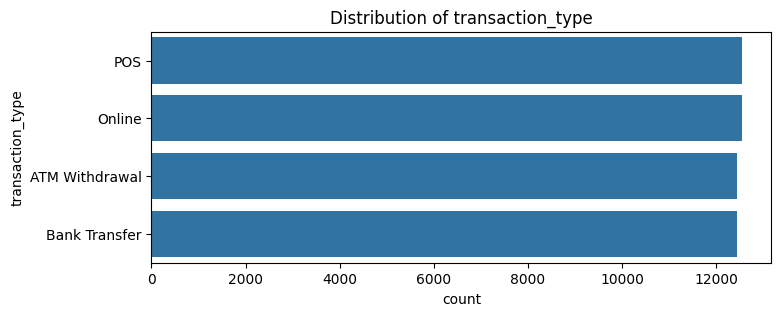

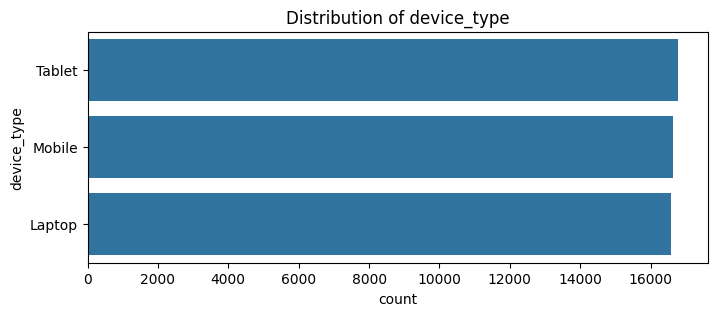

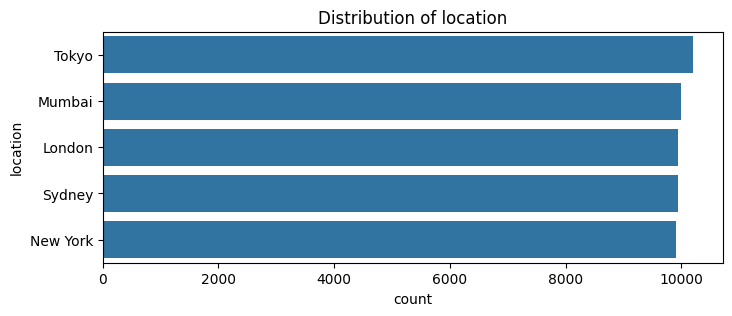

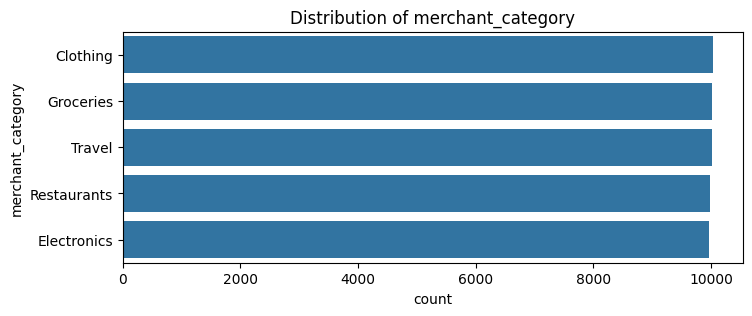

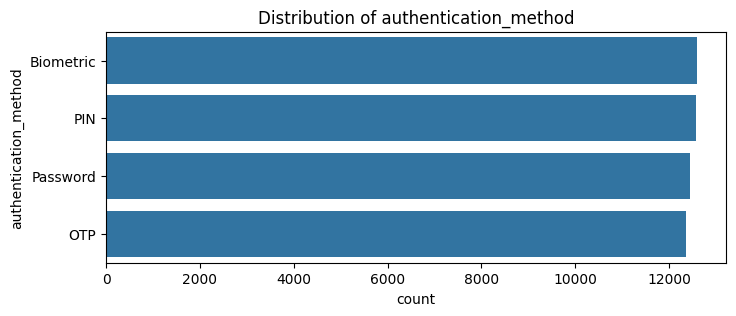

In [103]:
cat_cols = df.select_dtypes(include=["category"]).columns
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

### 8.Boxplots To Identify Outliers

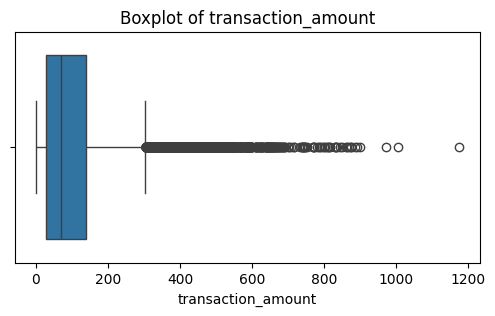

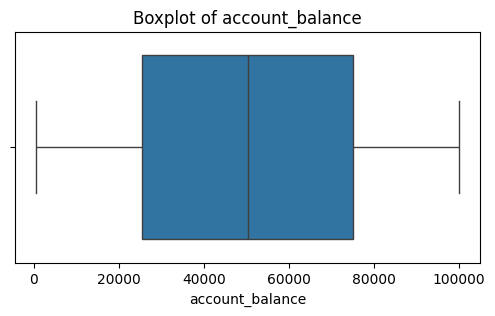

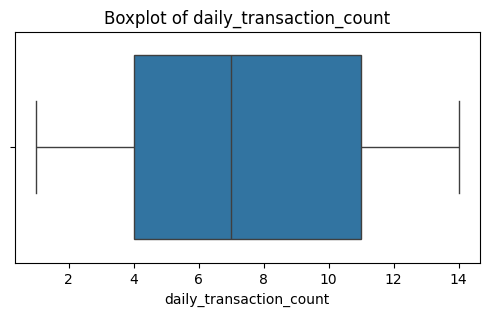

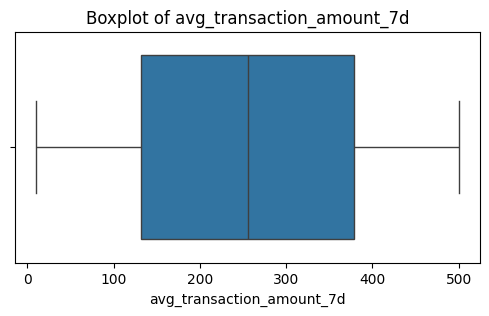

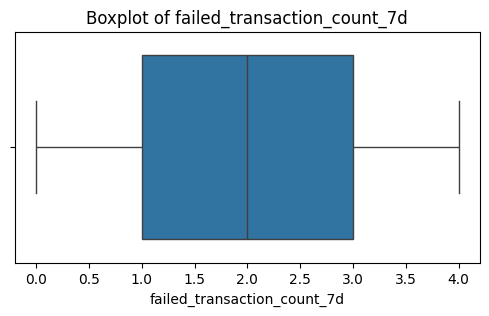

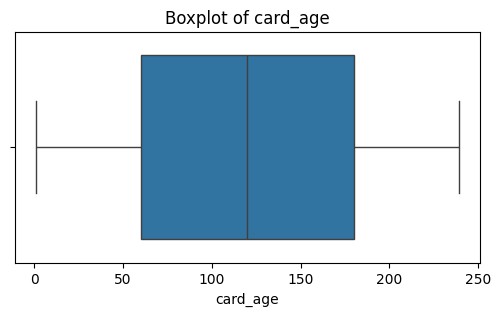

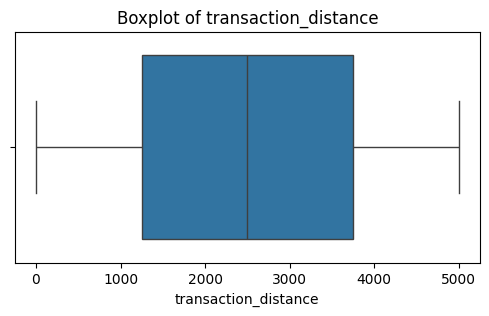

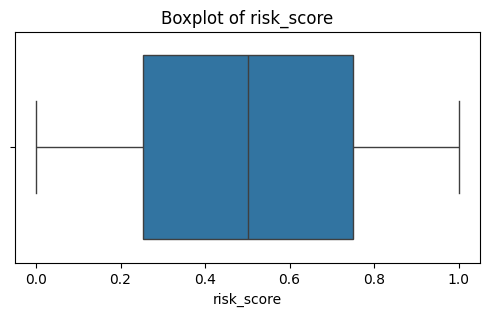

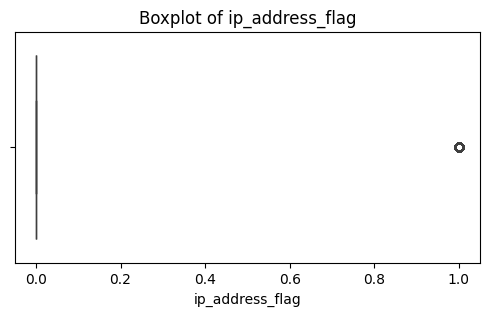

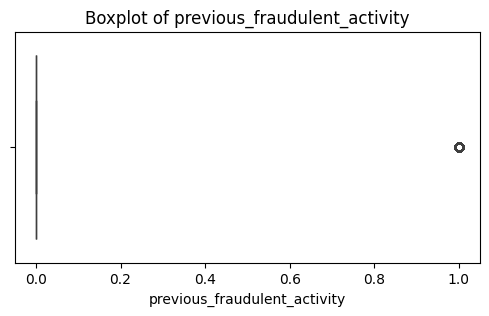

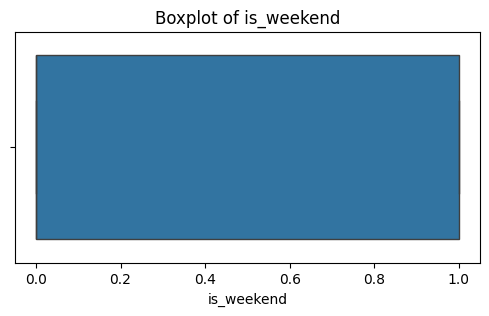

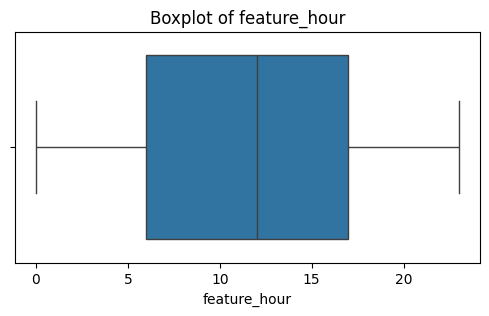

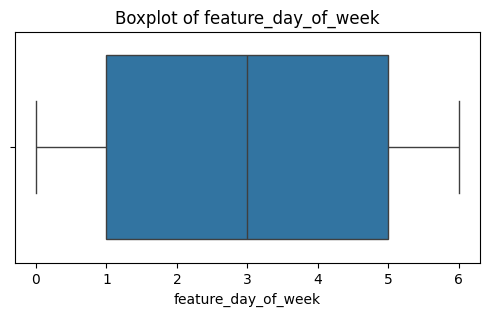

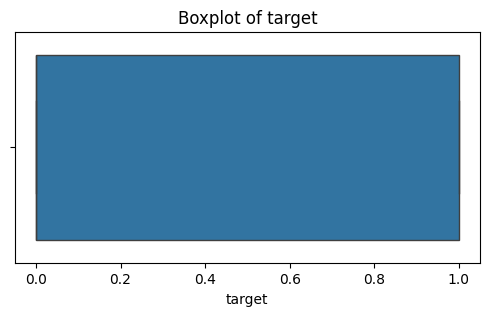

In [95]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### 9.Histograms

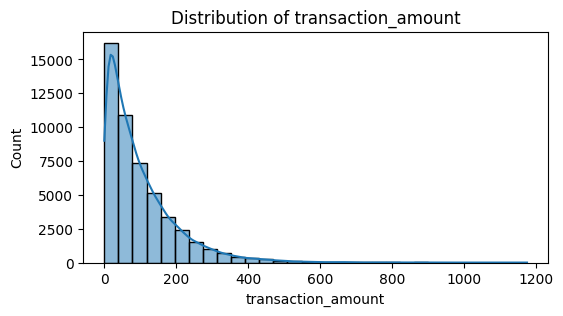

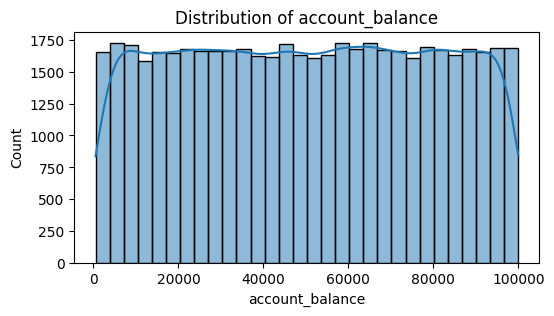

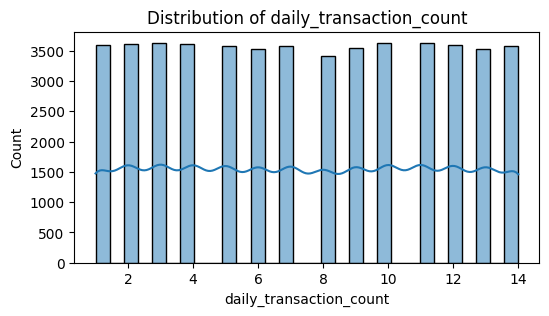

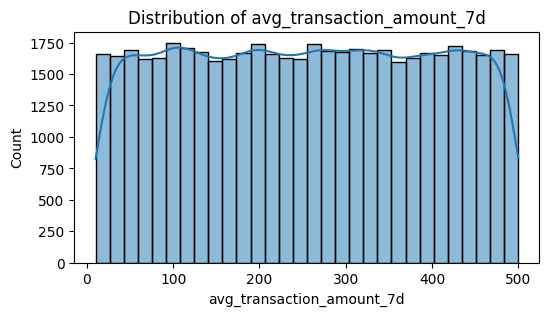

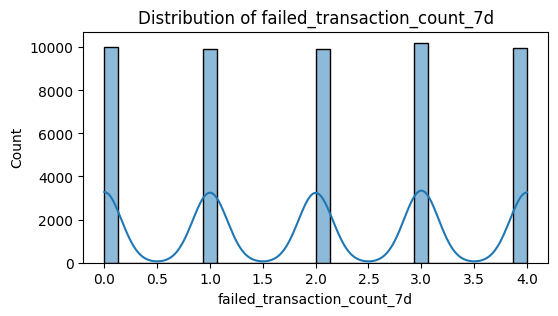

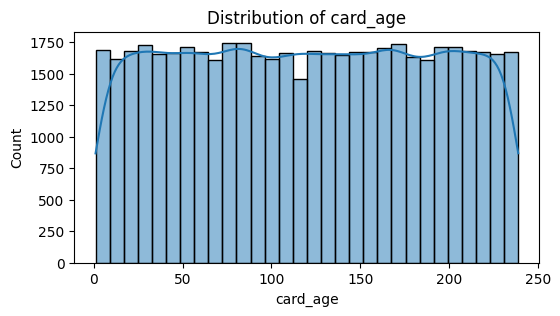

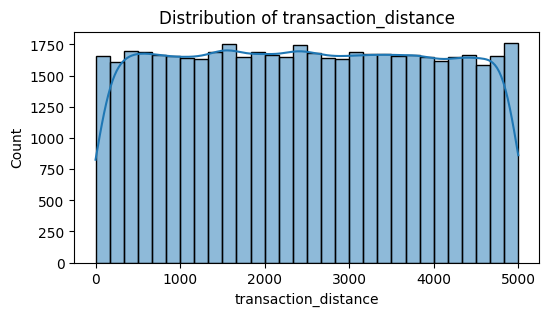

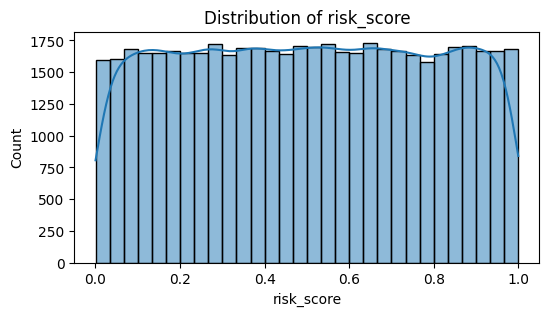

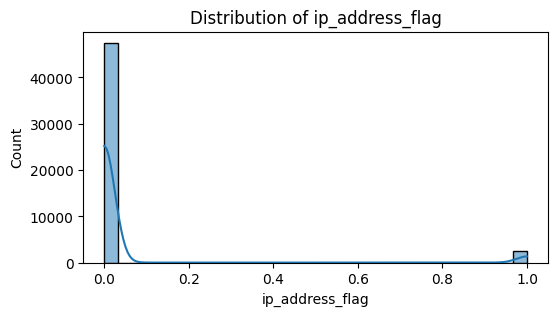

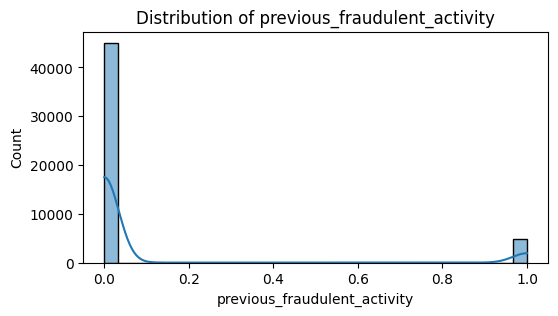

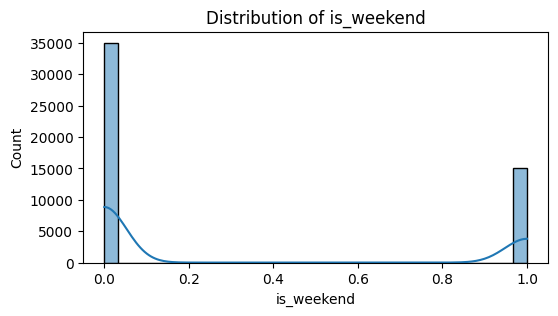

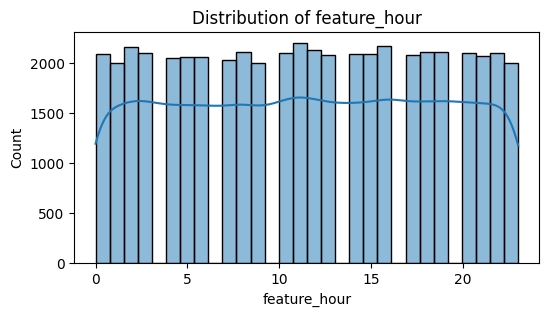

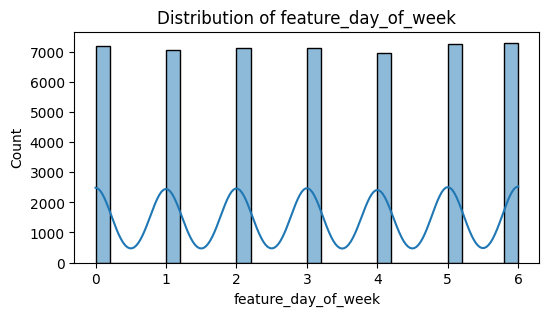

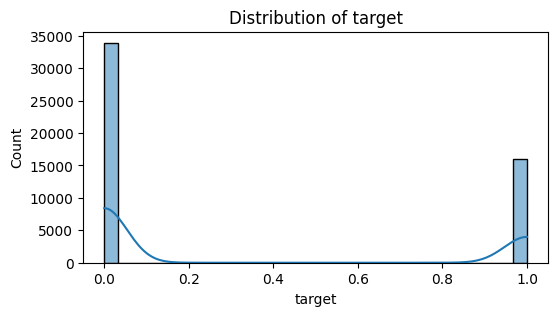

In [96]:
for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(data= df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

### 10.Heatmap Correlation

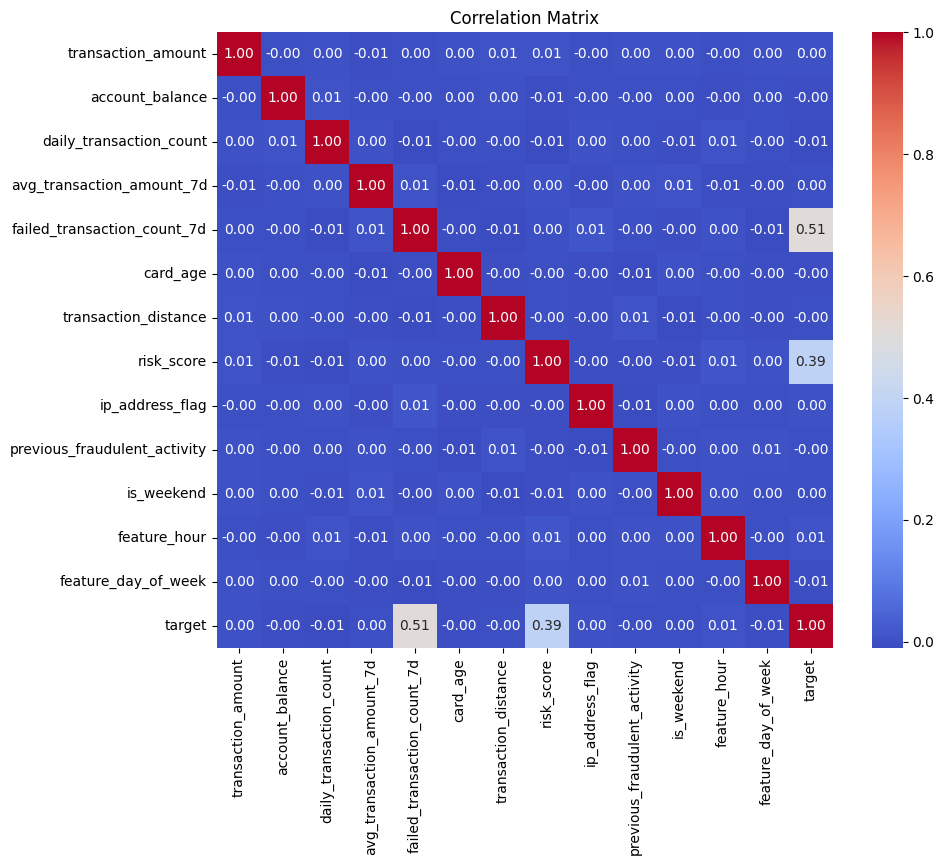

In [104]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

### 11.Target Class Distribution

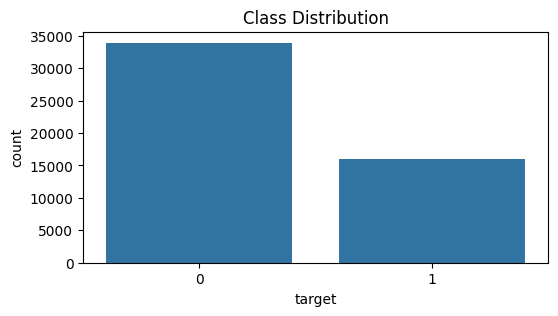

Class counts:
target
0    33933
1    16067
Name: count, dtype: int64


In [97]:
target = 'target'
if target in df.columns:
    plt.figure(figsize=(6, 3))
    sns.countplot(x=df[target])
    plt.title('Class Distribution')
    plt.show()
    print('Class counts:')
    print(df[target].value_counts())
else:
    print(f'Column {target} not found in the dataset.')